In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
fires = pd.read_csv("total_us_wildfires_1984_2024.csv")
fires = fires[fires["Year"].between(2000, 2023)]

In [3]:
def load_and_clean(path, state, var):
    df = pd.read_csv(path, comment="#")
    df = df.rename(columns={"Value": f"{state}_{var}"})
    df["Year"] = df["Date"].astype(str).str[:4].astype(int)
    return df[["Year", f"{state}_{var}"]]

In [4]:
climate_paths = {
    "CA_Temp": ("CATemp.csv", "CA", "Temp"),
    "CA_Precip": ("CAPrecip.csv", "CA", "Precip"),
    "AZ_Temp": ("AZTemp.csv", "AZ", "Temp"),
    "AZ_Precip": ("AZPrecip.csv", "AZ", "Precip"),
    "OR_Temp": ("ORTemp.csv", "OR", "Temp"),
    "OR_Precip": ("ORPrecip.csv", "OR", "Precip"),
}
climate_dfs = {k: load_and_clean(*v) for k, v in climate_paths.items()}

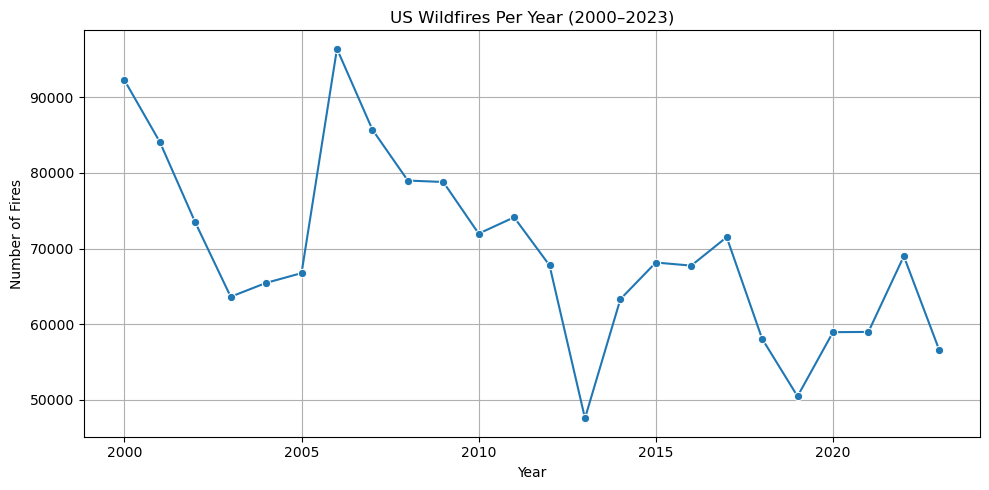

In [5]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=fires, x="Year", y="Fires", marker="o")
plt.title("US Wildfires Per Year (2000–2023)")
plt.xlabel("Year")
plt.ylabel("Number of Fires")
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
results = []
for label, df in climate_dfs.items():
    merged = fires.merge(df, on="Year")
    r, p = pearsonr(merged["Fires"], merged[df.columns[1]])
    results.append({"Variable": df.columns[1], "r": round(r, 3), "p-value": round(p, 3)})
correlation_df = pd.DataFrame(results)
print(correlation_df)

    Variable      r  p-value
0    CA_Temp -0.293    0.000
1  CA_Precip  0.079    0.182
2    AZ_Temp -0.052    0.377
3  AZ_Precip -0.211    0.000
4    OR_Temp -0.249    0.000
5  OR_Precip  0.181    0.002


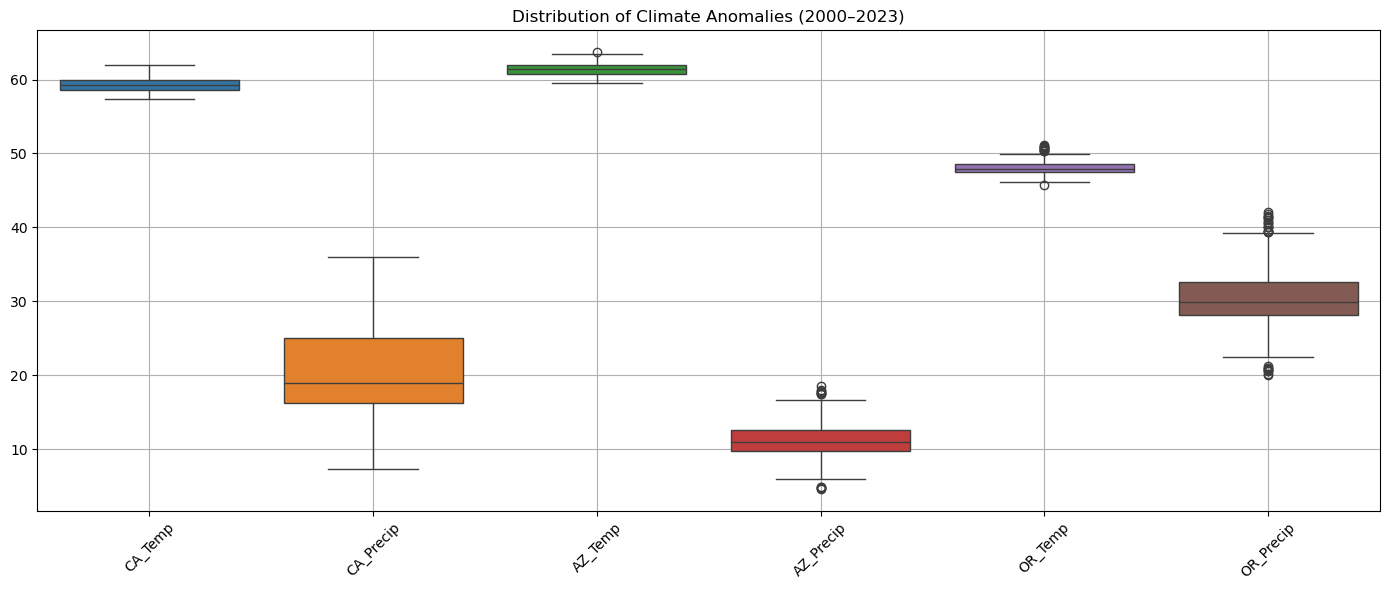

In [8]:
melted = pd.concat(climate_dfs.values(), axis=1)
melted = melted.loc[:, ~melted.columns.duplicated()]
melted = melted.drop(columns="Year")

plt.figure(figsize=(14, 6))
sns.boxplot(data=melted)
plt.xticks(rotation=45)
plt.title("Distribution of Climate Anomalies (2000–2023)")
plt.grid(True)
plt.tight_layout()
plt.show()

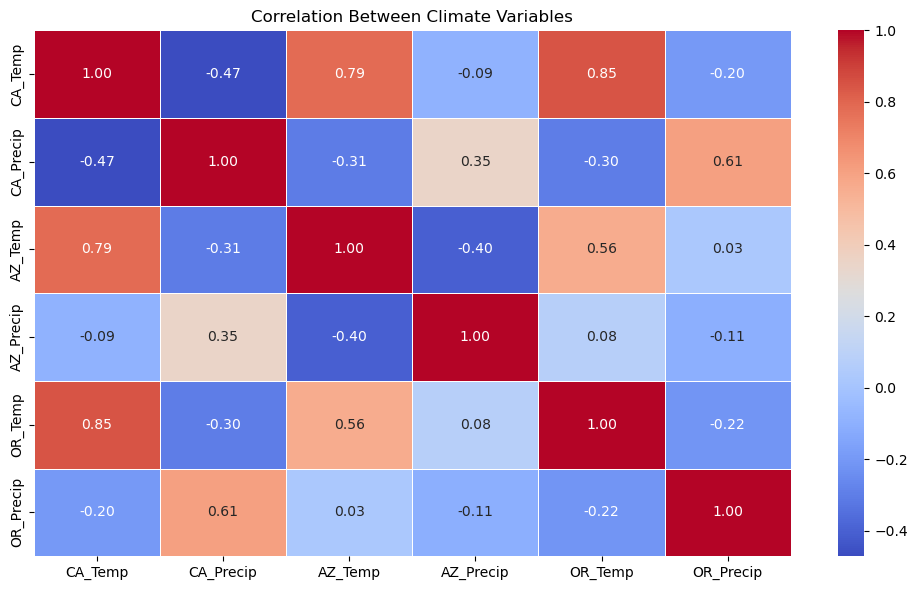

In [9]:
climate_corr = melted.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(climate_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Climate Variables")
plt.tight_layout()
plt.show()


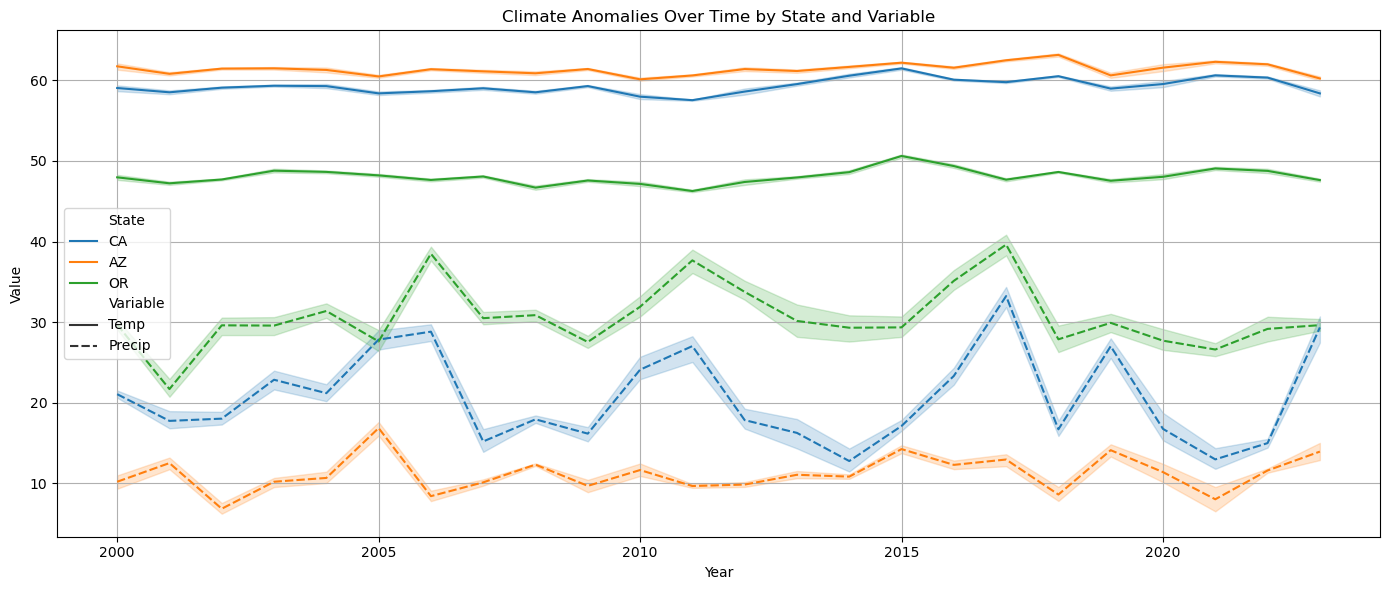

In [12]:
melted_long = []
for name, df in climate_dfs.items():
    state, var = name.split("_")
    temp_df = df.copy()
    temp_df["State"] = state
    temp_df["Variable"] = var
    temp_df = temp_df.rename(columns={f"{state}_{var}": "Value"})
    melted_long.append(temp_df)

melted_long = pd.concat(melted_long, ignore_index=True)

plt.figure(figsize=(14, 6))
sns.lineplot(data=melted_long, x="Year", y="Value", hue="State", style="Variable")
plt.title("Climate Anomalies Over Time by State and Variable")
plt.grid(True)
plt.tight_layout()
plt.show()